# Hafta 6 · Ders 11 — Tekil Değer Ayrışımı (SVD)

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Bu, kursun zirvesidir. **SVD**, *herhangi* bir matrisi — kare ya da dikdörtgen, tam ranklı
ya da değil — üç basit parçaya ayırır:

$$ A = U \Sigma V^\top $$

- $V^\top$ girdiyi **döndürür**,
- $\Sigma$ eksenler boyunca **gerer** (tekil değerler),
- $U$ çıktıyı **döndürür**.

Her doğrusal dönüşüm, ne kadar karmaşık olursa olsun, yalnızca *döndür → ger → döndür*tür. SVD'yi
$A^\top A$'nın özayrışımından (Hafta 5) kuracak, geometrisini Ders 3'teki elips olarak görecek ve
doruk dersini dolduran makine öğrenmesi uygulamalarını — PCA, sıkıştırma, ridge — kuracağız.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Geometri: döndür → ger → döndür

Bir matrisi birim çembere uygularsanız her zaman bir **elips** elde edersiniz (Ders 3). SVD, bu
resmin parçalarına isim verir: elipsin eksen yönleri $U$'nun sütunlarıdır, uzunlukları $\Sigma$'daki
tekil değerlerdir ve $V$ size hangi girdi yönlerinin onlara eşlendiğini söyler. Üçünü birden bir
arada görelim.

singular values: [3.618 1.382]


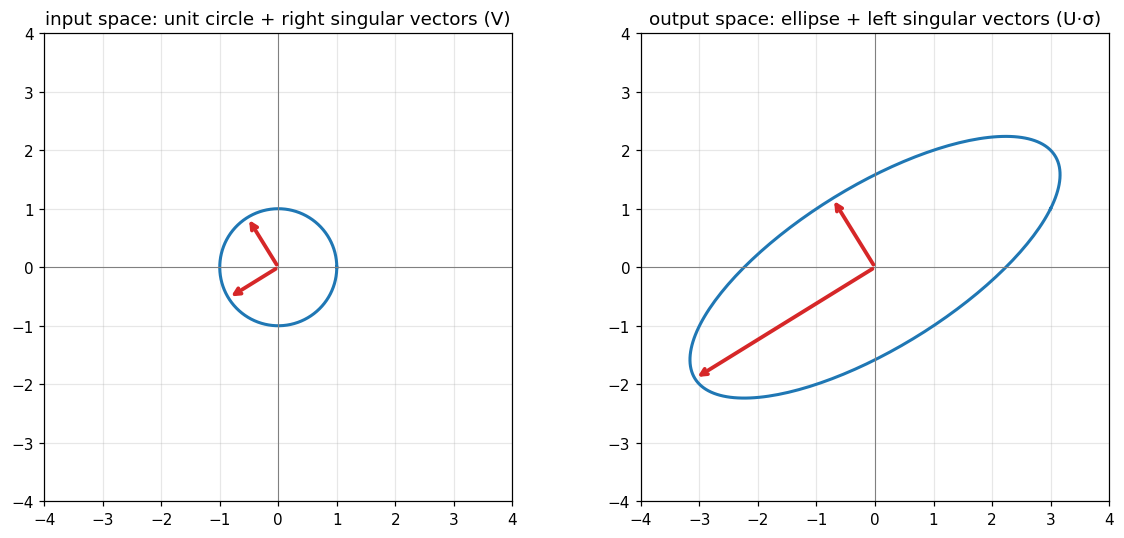

In [2]:
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])
U, s, Vt = np.linalg.svd(A)
print("tekil değerler:", s)

th = np.linspace(0, 2*np.pi, 200)
circle = np.stack([np.cos(th), np.sin(th)])
ellipse = A @ circle

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
# girdi: birim çember + sağ tekil vektörler V
axes[0].plot(circle[0], circle[1], color="C0", lw=2)
for k in range(2):
    v = Vt[k]
    axes[0].annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
axes[0].set_title("girdi uzayı: birim çember + sağ tekil vektörler (V)")
# çıktı: elips + ölçeklenmiş sol tekil vektörler U·σ
axes[1].plot(ellipse[0], ellipse[1], color="C0", lw=2)
for k in range(2):
    u = U[:, k] * s[k]
    axes[1].annotate("", xy=u, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
axes[1].set_title("çıktı uzayı: elips + sol tekil vektörler (U·σ)")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.7); ax.axvline(0, color="grey", lw=0.7)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.tight_layout(); plt.show()

## 2. SVD'yi özayrışımdan kurmak

SVD bir sihir değildir — kılık değiştirmiş hâliyle $A^\top A$'nın özayrışımıdır. Şunu gözlemleyin:

$$ A^\top A = V\Sigma^\top U^\top U \Sigma V^\top = V (\Sigma^\top\Sigma) V^\top $$

Yani **sağ tekil vektörler $V$**, simetrik $A^\top A$ matrisinin özvektörleridir ve **tekil değerler**,
onun (negatif olmayan) özdeğerlerinin karekökleridir. **Sol tekil vektörler** ise
$\mathbf{u}_i = A\mathbf{v}_i / \sigma_i$'den gelir. Tam olarak bunu uygulayalım.

In [3]:
def svd_from_scratch(A):
    A = np.asarray(A, float)
    # AᵀA'dan sağ tekil vektörler & tekil değerler (simetrik ⇒ eigh kullan)
    ATA = A.T @ A
    vals, V = np.linalg.eigh(ATA)
    idx = np.argsort(vals)[::-1]                 # azalan
    vals, V = vals[idx], V[:, idx]
    s = np.sqrt(np.clip(vals, 0, None))
    # sol tekil vektörler: u_i = A v_i / σ_i
    U = np.zeros((A.shape[0], len(s)))
    for i in range(len(s)):
        if s[i] > 1e-12:
            U[:, i] = A @ V[:, i] / s[i]
    return U, s, V.T

A = np.array([[3.0, 1.0],
              [1.0, 2.0],
              [0.0, 1.0]])
U, s, Vt = svd_from_scratch(A)
recon = U @ np.diag(s) @ Vt
check("A == U Σ Vᵀ (sıfırdan)", recon, A, atol=1e-8)
print("bizim tekil değerlerimiz:", s)
print("numpy tekil değerleri    :", np.linalg.svd(A, compute_uv=False))

[PASS] A == U Σ Vᵀ (from scratch)       max|Δ| = 1.11e-16
our singular values  : [3.6586 1.617 ]
numpy singular values: [3.6586 1.617 ]


## 3. NumPy ile doğrulama

Tekil *değerler* tekildir ve tam olarak eşleşmelidir. Tekil *vektörler* işaret bakımından (ya da
tekrarlayan tekil değerler için bir altuzay içinde dönme bakımından) farklılaşabilir; bu yüzden ham
vektörler yerine yeniden yapımları ve değerleri karşılaştırırız.

In [4]:
rng = np.random.default_rng(0)
M = rng.normal(size=(6, 4))
Um, sm, Vtm = svd_from_scratch(M)
check("tekil değerler numpy ile eşleşiyor", np.sort(sm)[::-1], np.sort(np.linalg.svd(M, compute_uv=False))[::-1], atol=1e-8)
check("yeniden yapım A == UΣVᵀ", Um @ np.diag(sm) @ Vtm, M, atol=1e-8)

[PASS] singular values match numpy      max|Δ| = 8.88e-16
[PASS] reconstruction A == UΣVᵀ         max|Δ| = 8.88e-16


True

## 4. Bağlantılar: SVD kursu birleştirir

Tekil değerler, önceki haftaların sorularını sessizce yanıtlar:

- **Rank** (Hafta 2) = sıfırdan farklı tekil değerlerin sayısı.
- **Koşul sayısı** (Hafta 5) = $\sigma_{\max}/\sigma_{\min}$ — neyi ölçtüğünü artık tam olarak görüyoruz.
- **Çekirdek uzayı** (Hafta 2) = $\sigma = 0$ olan sağ tekil vektörler.
- **Norm**: en büyük tekil değer, $A$'nın operatör (spektral) normudur.

Tek bir ayrışım ve tüm kurs ondan dökülüyor.

In [5]:
B = np.array([[1.0, 2.0, 3.0],
              [2.0, 4.0, 6.0],     # satır 2 = 2·satır 1 → rank eksik
              [1.0, 0.0, 1.0]])
_, s, _ = np.linalg.svd(B)
print("tekil değerler:", s)
print("sayısal rank (σ > 1e-10):", int(np.sum(s > 1e-10)), " vs np.linalg.matrix_rank:", np.linalg.matrix_rank(B))
print("koşul sayısı σ_max/σ_min(sıfırdan farklı):", round(s[0] / s[s > 1e-10][-1], 2))

singular values: [8.4354 0.9183 0.    ]
numerical rank (σ > 1e-10): 2  vs np.linalg.matrix_rank: 2
condition number σ_max/σ_min(nonzero): 9.19


## 5. Bunun makine öğrenmesinde karşımıza çıktığı yer (başrol)

SVD, tartışmasız makine öğrenmesinin *en önemli* matris ayrışımıdır:

- **PCA**, merkezlenmiş veri matrisinin SVD'sidir (sonraki ve son ders).
- **Düşük ranklı yaklaşım**, yalnızca en büyük tekil değerleri tutar — görüntü sıkıştırma,
  öneri sistemleri ve büyük modellerin LoRA ile ince ayarının temeli.
- **Gizli anlamsal analiz (LSA)**, konuları bulmak için bir terim–belge matrisini SVD ile ayrıştırır.
- **Sözde-ters & kararlı en küçük kareler**, hepsinin en sağlam çözücüsü olan SVD aracılığıyla tanımlanır.

Sıkıştırmaya hızlı bir önizleme: ranka yakın eksik bir matrisin yalnızca en büyük tekil değerini tutun ve
ne kadarının geri kazanıldığını görün.

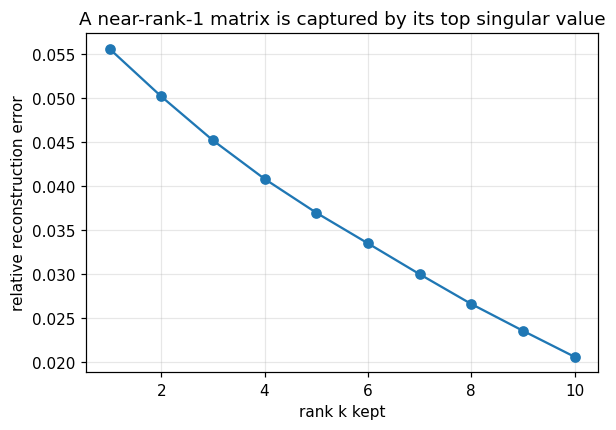

rank-1 approximation already captures 94.4% of the matrix.


In [6]:
rng = np.random.default_rng(2)
# neredeyse rank 1 olan bir matris
base = rng.normal(size=(20, 1)) @ rng.normal(size=(1, 20))
A = base + 0.05 * rng.normal(size=(20, 20))
U, s, Vt = np.linalg.svd(A)

def rank_k_approx(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

errs = [np.linalg.norm(A - rank_k_approx(U, s, Vt, k)) / np.linalg.norm(A) for k in range(1, 11)]
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), errs, "o-", color="C0")
plt.xlabel("tutulan rank k"); plt.ylabel("göreli yeniden yapım hatası")
plt.title("Neredeyse rank-1 bir matris en büyük tekil değeriyle yakalanır")
plt.grid(True, alpha=0.3); plt.show()
print(f"rank-1 yaklaşımı matrisin zaten %{100*(1-errs[0]):.1f}'ini yakalıyor.")

## Alıştırmalar

1. **İnce SVD.** Uzun bir $m\times n$ matris için ($m>n$), "ince" SVD $U$'yu $m\times n$ olarak tutar. $A$'yı yine de yeniden ürettiğini ve depolama tasarrufu sağladığını doğrulayın.
2. **Simetrik bir matrisin SVD'si.** Simetrik pozitif tanımlı bir matris için SVD ile özayrışımın çakıştığını (tekil değerler = özdeğerler) gösterin.
3. **Sözde-ters.** $A^+ = V\Sigma^{-1}U^\top$ kurun (yalnızca sıfırdan farklı tekil değerleri tersleyerek) ve en küçük kareleri çözdüğünü, `np.linalg.pinv` ile eşleştiğini doğrulayın.

In [7]:
# === Çözümler (önce kendiniz deneyin!) ===

# 2. simetrik pozitif tanımlı: SVD ≡ özayrışım
rng = np.random.default_rng(3)
M = rng.normal(size=(4, 4)); S = M @ M.T          # SPD
sv = np.linalg.svd(S, compute_uv=False)
ev = np.sort(np.linalg.eigvalsh(S))[::-1]
check("tekil değerler == özdeğerler (SPD)", np.sort(sv)[::-1], ev, atol=1e-8)

# 3. SVD'den sözde-ters
A = rng.normal(size=(6, 3))
U, s, Vt = np.linalg.svd(A, full_matrices=False)
A_pinv = Vt.T @ np.diag(1.0 / s) @ U.T
check("bizim sözde-ters == np.linalg.pinv", A_pinv, np.linalg.pinv(A), atol=1e-8)

[PASS] singular values == eigenvalues (SPD) max|Δ| = 7.11e-15
[PASS] our pseudo-inverse == np.linalg.pinv max|Δ| = 5.55e-17


True

## Özet ve sırada ne var

$A = U\Sigma V^\top$, her matrisin döndür–ger–döndür olduğunu söyler. Bunu $A^\top A$'nın özayrışımından
kurduk ve rankın, koşul sayısının ve çekirdek uzayının tekil değerlerden nasıl ortaya çıktığını izledik.

**Sırada — `12_pca_dusuk_rank_doruk_projesi.ipynb`:** finalimiz. **PCA**'yı SVD'den türetir, düşük ranklı yaklaşımla
bir görüntüyü sıkıştırır, ridge regresyonunu SVD merceğinden görür ve boyut indirgemeyi çalışan bir
modele bağlarız — "veri, vektörlerden oluşan bir buluttur"dan eğitilmiş bir tahmin ediciye kadar olan
döngüyü kapatırız.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 6 · Ders 11*